# 04 Business EDA

This notebook executes Part 2 of the competition: business-focused exploratory data analysis. It keeps only report-ready insights. Each insight has an analysis dataset, a clean chart, and a short explanation with implication and recommendation.

Required R packages: `dplyr`, `ggplot2`, `tidyr`, `lubridate`, and `scales`.


## 1. Setup

Power BI can support dashboard polishing later, but the core metrics and charts in this notebook are produced from R code.


In [ ]:
library(dplyr)
library(ggplot2)
library(tidyr)
library(lubridate)
library(scales)

options(scipen = 999)

project_root <- normalizePath(getwd(), winslash = "/", mustWork = TRUE)
while (!dir.exists(file.path(project_root, "dataset")) && dirname(project_root) != project_root) {
  project_root <- dirname(project_root)
}

data_dir <- file.path(project_root, "dataset")
artifact_dir <- file.path(project_root, "artifacts", "business_eda")
chart_dir <- file.path(artifact_dir, "charts")
dir.create(chart_dir, recursive = TRUE, showWarnings = FALSE)

theme_minimal(base_size = 11) |> theme_set()
fmt_money <- function(x) dollar(x, prefix = "", big.mark = ",", accuracy = 1)
fmt_pct <- function(x) percent(x, accuracy = 0.1)

print(project_root)
print(artifact_dir)



Attaching package: 'dplyr'




The following objects are masked from 'package:stats':

    filter, lag




The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union





Attaching package: 'lubridate'




The following objects are masked from 'package:base':

    date, intersect, setdiff, union




[1] "C:/Users/admin/OneDrive - National Economics University/Documents/NCKH/DATATHON/Neu_BRT_Datathon"


[1] "C:/Users/admin/OneDrive - National Economics University/Documents/NCKH/DATATHON/Neu_BRT_Datathon/artifacts/business_eda"


## 2. Load Data

All joins use only the provided competition CSV files.


In [ ]:
orders <- read.csv(file.path(data_dir, "orders.csv"), stringsAsFactors = FALSE) |>
  mutate(order_date = as.Date(order_date))
order_items <- read.csv(file.path(data_dir, "order_items.csv"), stringsAsFactors = FALSE)
products <- read.csv(file.path(data_dir, "products.csv"), stringsAsFactors = FALSE)
customers <- read.csv(file.path(data_dir, "customers.csv"), stringsAsFactors = FALSE) |>
  mutate(signup_date = as.Date(signup_date))
geography <- read.csv(file.path(data_dir, "geography.csv"), stringsAsFactors = FALSE)
returns <- read.csv(file.path(data_dir, "returns.csv"), stringsAsFactors = FALSE) |>
  mutate(return_date = as.Date(return_date))
reviews <- read.csv(file.path(data_dir, "reviews.csv"), stringsAsFactors = FALSE) |>
  mutate(review_date = as.Date(review_date))
shipments <- read.csv(file.path(data_dir, "shipments.csv"), stringsAsFactors = FALSE) |>
  mutate(ship_date = as.Date(ship_date), delivery_date = as.Date(delivery_date))
inventory <- read.csv(file.path(data_dir, "inventory.csv"), stringsAsFactors = FALSE) |>
  mutate(snapshot_date = as.Date(snapshot_date))
web_traffic <- read.csv(file.path(data_dir, "web_traffic.csv"), stringsAsFactors = FALSE) |>
  mutate(date = as.Date(date))
promotions <- read.csv(file.path(data_dir, "promotions.csv"), stringsAsFactors = FALSE) |>
  mutate(start_date = as.Date(start_date), end_date = as.Date(end_date))
sales <- read.csv(file.path(data_dir, "sales.csv"), stringsAsFactors = FALSE) |>
  mutate(Date = as.Date(Date))

tibble::tibble(
  table = c("orders", "order_items", "products", "customers", "geography", "returns", "reviews", "shipments", "inventory", "web_traffic", "promotions", "sales"),
  rows = c(nrow(orders), nrow(order_items), nrow(products), nrow(customers), nrow(geography), nrow(returns), nrow(reviews), nrow(shipments), nrow(inventory), nrow(web_traffic), nrow(promotions), nrow(sales))
)


table,rows
<chr>,<int>
orders,646945
order_items,714669
products,2412
customers,121930
geography,39948
returns,39939
reviews,113551
shipments,566067
inventory,60247


## 3. Core Analysis Datasets

These datasets are created once and reused across themes so metrics stay consistent.


In [ ]:
order_lines_enriched <- order_items |>
  left_join(orders, by = "order_id") |>
  left_join(products, by = "product_id") |>
  left_join(customers |> select(customer_id, age_group, gender, acquisition_channel), by = "customer_id") |>
  left_join(geography |> select(zip, region, district), by = "zip") |>
  mutate(
    order_month = floor_date(order_date, "month"),
    order_quarter = paste0(year(order_date), " Q", quarter(order_date)),
    line_revenue = quantity * unit_price,
    line_cogs = quantity * cogs,
    gross_margin = line_revenue - line_cogs,
    discount_rate = ifelse(line_revenue > 0, discount_amount / line_revenue, NA_real_)
  )

sales_monthly <- sales |>
  mutate(month = floor_date(Date, "month"), year = year(Date), month_num = month(Date), quarter = quarter(Date)) |>
  group_by(month) |>
  summarise(revenue = sum(Revenue, na.rm = TRUE), cogs = sum(COGS, na.rm = TRUE), gross_margin = revenue - cogs, .groups = "drop")

traffic_daily <- web_traffic |>
  mutate(session_weight = sessions) |>
  group_by(date) |>
  summarise(
    sessions = sum(sessions, na.rm = TRUE),
    unique_visitors = sum(unique_visitors, na.rm = TRUE),
    page_views = sum(page_views, na.rm = TRUE),
    bounce_rate = weighted.mean(bounce_rate, session_weight, na.rm = TRUE),
    avg_session_duration_sec = weighted.mean(avg_session_duration_sec, session_weight, na.rm = TRUE),
    .groups = "drop"
  )

returns_enriched <- returns |>
  left_join(products |> select(product_id, category, segment, size), by = "product_id") |>
  left_join(orders |> select(order_id, order_date, zip), by = "order_id") |>
  left_join(geography |> select(zip, region), by = "zip")

experience_data <- reviews |>
  left_join(products |> select(product_id, category, segment, size), by = "product_id") |>
  left_join(shipments |> mutate(delivery_delay_days = as.numeric(delivery_date - ship_date)) |> select(order_id, delivery_delay_days, shipping_fee), by = "order_id") |>
  mutate(delay_bucket = cut(delivery_delay_days, breaks = c(-Inf, 2, 5, 10, Inf), labels = c("0-2 days", "3-5 days", "6-10 days", "10+ days")))

inventory_monthly <- inventory |> mutate(month = floor_date(snapshot_date, "month"))

tibble::tibble(
  dataset = c("order_lines_enriched", "sales_monthly", "traffic_daily", "returns_enriched", "experience_data", "inventory_monthly"),
  grain = c("order item line", "month", "date", "return record", "review record", "product-month"),
  main_use = c("Revenue, demand, product, customer, channel", "Revenue trend and seasonality", "Traffic quality", "Returns and refund pressure", "Rating and shipping delay", "Stockout, fill rate, overstock, sell-through")
)


dataset,grain,main_use
<chr>,<chr>,<chr>
order_lines_enriched,order item line,"Revenue, demand, product, customer, channel"
sales_monthly,month,Revenue trend and seasonality
traffic_daily,date,Traffic quality
returns_enriched,return record,Returns and refund pressure
experience_data,review record,Rating and shipping delay
inventory_monthly,product-month,"Stockout, fill rate, overstock, sell-through"


# Theme 1: Revenue And Demand


## Insight 1 - Demand is seasonal, and category mix is highly concentrated

**Business question:** Which time periods and product categories should drive revenue planning and campaign timing?


In [ ]:
revenue_demand_data <- order_lines_enriched |>
  group_by(order_month, category) |>
  summarise(revenue = sum(line_revenue, na.rm = TRUE), units = sum(quantity, na.rm = TRUE), gross_margin = sum(gross_margin, na.rm = TRUE), .groups = "drop")

category_contribution <- order_lines_enriched |>
  group_by(category) |>
  summarise(revenue = sum(line_revenue, na.rm = TRUE), units = sum(quantity, na.rm = TRUE), gross_margin = sum(gross_margin, na.rm = TRUE), .groups = "drop") |>
  mutate(revenue_share = revenue / sum(revenue)) |>
  arrange(desc(revenue))

peak_month <- sales_monthly |> slice_max(revenue, n = 1, with_ties = FALSE)
low_month <- sales_monthly |> slice_min(revenue, n = 1, with_ties = FALSE)
top_category <- category_contribution |> slice_max(revenue, n = 1, with_ties = FALSE)
top3_share <- category_contribution |> slice_max(revenue, n = 3, with_ties = FALSE) |> summarise(share = sum(revenue_share)) |> pull(share)

category_contribution


category,revenue,units,gross_margin,revenue_share
<chr>,<dbl>,<int>,<dbl>,<dbl>
Streetwear,13131346353,1768826,1738676765,0.79920666
Outdoor,2494882754,1170000,408520049,0.15184482
Casual,460648383,107469,54103955,0.02803622
GenZ,343599095,166848,65725297,0.02091230


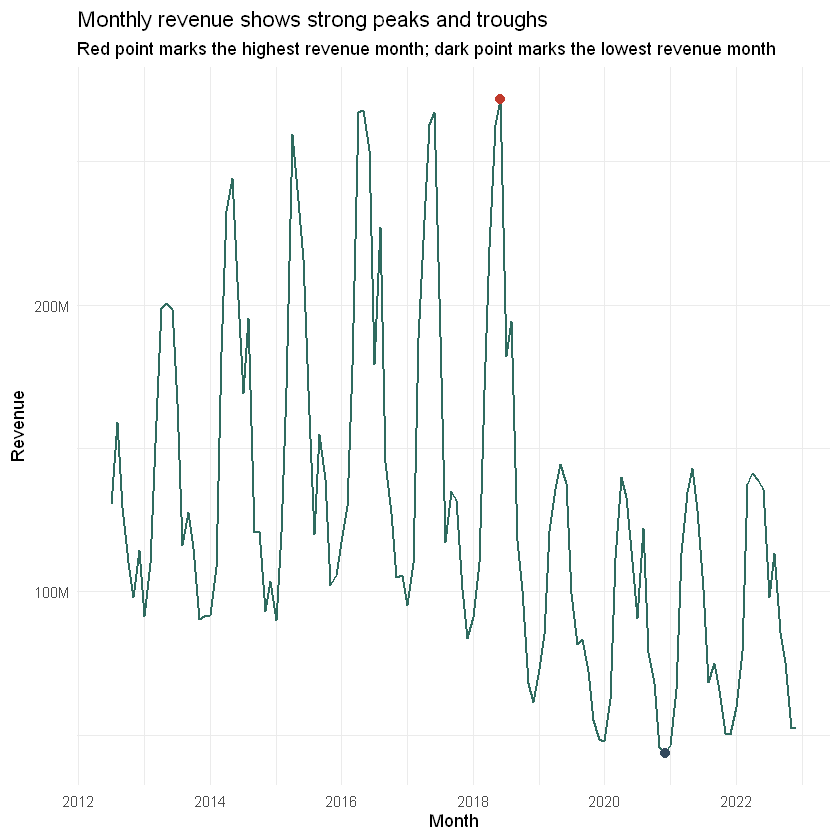

In [ ]:
p1 <- ggplot(sales_monthly, aes(x = month, y = revenue)) +
  geom_line(color = "#2F6B5F", linewidth = 0.7) +
  geom_point(data = peak_month, aes(x = month, y = revenue), color = "#C0392B", size = 2.5) +
  geom_point(data = low_month, aes(x = month, y = revenue), color = "#34495E", size = 2.5) +
  scale_y_continuous(labels = label_number(scale_cut = cut_short_scale())) +
  labs(
    title = "Monthly revenue shows strong peaks and troughs",
    subtitle = "Red point marks the highest revenue month; dark point marks the lowest revenue month",
    x = "Month",
    y = "Revenue"
  )

p1
ggsave(file.path(chart_dir, "insight_01_monthly_revenue.png"), p1, width = 9, height = 5, dpi = 160)


**What it shows:** Monthly revenue is not flat; planning must account for demand peaks and troughs.

**Key numbers:** The highest revenue month is **2018-06** with about **271,674,172** revenue. The lowest revenue month is **2020-12** with about **43,671,564** revenue. At line-item level, **Streetwear** contributes about **79.9%** of revenue, and the top three categories contribute about **97.9%**.

**Why it matters:** A small number of categories drive most revenue, so poor stock or weak campaigns in those categories can move total business performance.

**Implication:** Seasonal demand planning should be category-aware, not only total-revenue based.

**Recommendation:** Build the report and operational plan around high-impact categories first, especially Streetwear. Before peak months, reserve inventory and marketing budget for the categories that dominate revenue and margin.


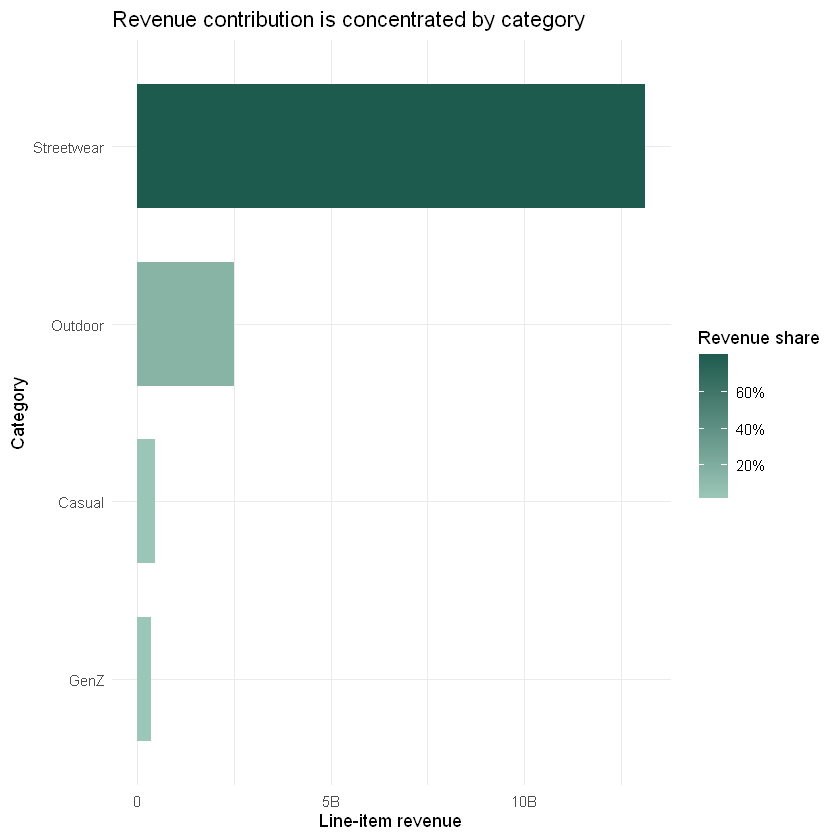

In [ ]:
p1b <- category_contribution |>
  mutate(category = reorder(category, revenue)) |>
  ggplot(aes(x = category, y = revenue, fill = revenue_share)) +
  geom_col(width = 0.7) +
  coord_flip() +
  scale_y_continuous(labels = label_number(scale_cut = cut_short_scale())) +
  scale_fill_gradient(low = "#9CC7B8", high = "#1E5B4F", labels = percent) +
  labs(title = "Revenue contribution is concentrated by category", x = "Category", y = "Line-item revenue", fill = "Revenue share")

p1b
ggsave(file.path(chart_dir, "insight_01_category_contribution.png"), p1b, width = 8, height = 5, dpi = 160)


# Theme 2: Customer And Channel


## Insight 2 - Channel decisions should balance revenue, AOV, and session quality

**Business question:** Which channels look valuable after considering order value and traffic quality instead of only order volume?


In [ ]:
channel_order_data <- order_lines_enriched |>
  group_by(order_source, device_type) |>
  summarise(revenue = sum(line_revenue, na.rm = TRUE), orders = n_distinct(order_id), customers = n_distinct(customer_id), units = sum(quantity, na.rm = TRUE), .groups = "drop") |>
  mutate(aov = revenue / orders, orders_per_customer = orders / customers)

channel_summary <- channel_order_data |>
  group_by(order_source) |>
  summarise(revenue = sum(revenue), orders = sum(orders), customers = sum(customers), aov = revenue / orders, orders_per_customer = orders / customers, .groups = "drop") |>
  arrange(desc(revenue))

traffic_quality <- web_traffic |>
  mutate(session_weight = sessions) |>
  group_by(traffic_source) |>
  summarise(sessions = sum(sessions, na.rm = TRUE), bounce_rate = weighted.mean(bounce_rate, session_weight, na.rm = TRUE), avg_session_duration_sec = weighted.mean(avg_session_duration_sec, session_weight, na.rm = TRUE), .groups = "drop") |>
  arrange(bounce_rate)

channel_summary
traffic_quality


order_source,revenue,orders,customers,aov,orders_per_customer
<chr>,<dbl>,<int>,<int>,<dbl>,<dbl>
organic_search,4595516711,181495,101306,25320.35,1.791552
paid_search,3606943187,141652,86754,25463.41,1.632801
social_media,3289598708,129710,81875,25361.18,1.584244
email_campaign,1972621080,77572,57034,25429.55,1.360101
referral,1640764180,64565,49538,25412.59,1.303343
direct,1325032720,51951,41652,25505.43,1.247263


traffic_source,sessions,bounce_rate,avg_session_duration_sec
<chr>,<int>,<dbl>,<dbl>
email_campaign,12792670,0.004435253,212.4599
social_media,15816226,0.004474762,210.9789
paid_search,19598271,0.004479334,208.2681
organic_search,27196976,0.004498484,211.0811
direct,6571549,0.004520987,206.0632
referral,9476845,0.004526818,205.8840


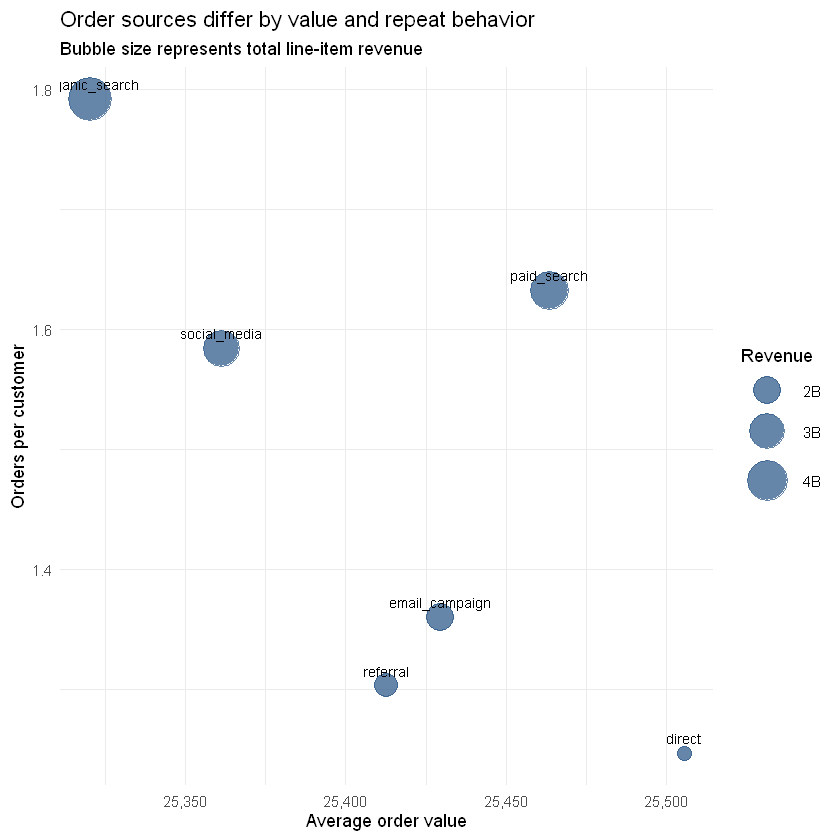

In [ ]:
p2 <- ggplot(channel_summary, aes(x = aov, y = orders_per_customer, size = revenue, label = order_source)) +
  geom_point(color = "#315C8C", alpha = 0.75) +
  geom_text(vjust = -0.9, size = 3) +
  scale_x_continuous(labels = label_number(big.mark = ",")) +
  scale_size_continuous(labels = label_number(scale_cut = cut_short_scale()), range = c(4, 12)) +
  labs(title = "Order sources differ by value and repeat behavior", subtitle = "Bubble size represents total line-item revenue", x = "Average order value", y = "Orders per customer", size = "Revenue")

p2
ggsave(file.path(chart_dir, "insight_02_channel_value.png"), p2, width = 8, height = 5, dpi = 160)


**What it shows:** Order sources should not be judged by volume alone. The best source for total revenue can differ from the best source for average order value.

**Key numbers:** `organic_search` contributes about **4,595,516,711** line-item revenue, with AOV around **25,320** and about **2.99** orders per customer. `direct` has the highest AOV at about **25,505**. For traffic quality, `email_campaign` has the lowest average bounce rate at about **0.0045**, while `direct` is the highest, also around **0.0045** but slightly worse.

**Why it matters:** Marketing allocation should optimize for revenue quality and repeat behavior, not just sessions or order counts.

**Implication:** Channels with strong AOV or repeat behavior deserve retention and upsell tests; high-bounce traffic needs landing-page or targeting review.

**Recommendation:** Use `organic_search` as a core revenue engine, protect SEO/product discoverability, and run controlled improvements for sources with weaker bounce or repeat behavior. Track AOV and repeat rate as channel KPIs.


# Theme 3: Returns And Customer Experience


## Insight 3 - Return pressure is tied to product fit and refund cost

**Business question:** Which product groups create the most avoidable return and refund pressure?


In [ ]:
return_denominator <- order_lines_enriched |>
  group_by(category, segment, size) |>
  summarise(order_item_rows = n(), .groups = "drop")

return_numerator <- returns_enriched |>
  group_by(category, segment, size) |>
  summarise(return_records = n(), return_quantity = sum(return_quantity, na.rm = TRUE), refund_amount = sum(refund_amount, na.rm = TRUE), .groups = "drop")

return_rate_data <- return_denominator |>
  left_join(return_numerator, by = c("category", "segment", "size")) |>
  mutate(return_records = replace_na(return_records, 0), return_quantity = replace_na(return_quantity, 0), refund_amount = replace_na(refund_amount, 0), return_rate = return_records / order_item_rows) |>
  arrange(desc(return_rate))

return_reason_data <- returns_enriched |>
  count(return_reason, sort = TRUE, name = "records") |>
  mutate(record_share = records / sum(records))

return_rate_data |> head(12)
return_reason_data


category,segment,size,order_item_rows,return_records,return_quantity,refund_amount,return_rate
<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>
Casual,Activewear,S,346,23,60,309484.2,0.06647399
Streetwear,Standard,L,2167,137,369,1678604.9,0.06322104
GenZ,Trendy,XL,5393,333,906,2395077.2,0.06174671
Casual,Activewear,L,364,22,60,303209.1,0.06043956
Casual,Activewear,XL,354,21,57,277149.2,0.05932203
Casual,Activewear,M,357,21,67,338687.2,0.05882353
Streetwear,Performance,L,24410,1419,3899,16635969.1,0.05813191
GenZ,Trendy,M,10275,597,1666,3436958.4,0.05810219
Outdoor,Activewear,S,45907,2663,7395,12795038.6,0.05800858


return_reason,records,record_share
<chr>,<int>,<dbl>
wrong_size,13967,0.3497083
defective,8020,0.2008062
not_as_described,7035,0.1761436
changed_mind,6931,0.1735396
late_delivery,3986,0.0998022


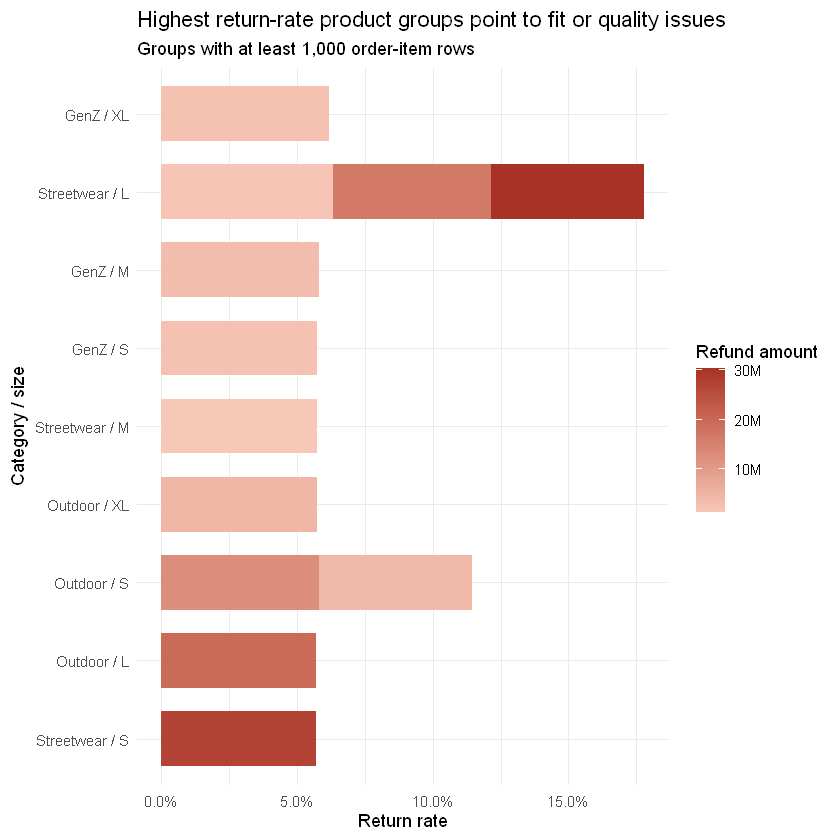

In [ ]:
p3 <- return_rate_data |>
  filter(order_item_rows >= 1000) |>
  slice_max(return_rate, n = 12, with_ties = FALSE) |>
  mutate(group = reorder(paste(category, size, sep = " / "), return_rate)) |>
  ggplot(aes(x = group, y = return_rate, fill = refund_amount)) +
  geom_col(width = 0.7) +
  coord_flip() +
  scale_y_continuous(labels = percent_format(accuracy = 0.1)) +
  scale_fill_gradient(low = "#F7C7B8", high = "#A93226", labels = label_number(scale_cut = cut_short_scale())) +
  labs(title = "Highest return-rate product groups point to fit or quality issues", subtitle = "Groups with at least 1,000 order-item rows", x = "Category / size", y = "Return rate", fill = "Refund amount")

p3
ggsave(file.path(chart_dir, "insight_03_return_rate.png"), p3, width = 8, height = 5, dpi = 160)


**What it shows:** Return risk is not evenly distributed; it concentrates in specific category-size combinations.

**Key numbers:** The highest return-rate group is **GenZ / XL**, with return rate around **6.17%**, **333** return records, and about **2,395,077** refund amount. The most common return reason overall is **wrong_size**, with **13,967** records.

**Why it matters:** Returns directly reduce net revenue and create reverse-logistics cost. A high share of `wrong_size` points to a fixable fit-information problem rather than random dissatisfaction.

**Implication:** Product detail pages, sizing guides, and fit recommendations can reduce avoidable returns.

**Recommendation:** Prioritize size-guide improvements and product-page fit warnings for high-return category-size combinations. Track return rate by size after the change as the success metric.


## Insight 4 - Delivery experience has measurable customer-experience risk

**Business question:** Does shipping delay relate to rating outcomes and return management priorities?


In [ ]:
shipping_experience_data <- experience_data |>
  filter(!is.na(delay_bucket)) |>
  group_by(delay_bucket) |>
  summarise(reviews = n(), avg_rating = mean(rating, na.rm = TRUE), median_delay_days = median(delivery_delay_days, na.rm = TRUE), .groups = "drop")

return_delay_data <- returns_enriched |>
  left_join(shipments |> mutate(delivery_delay_days = as.numeric(delivery_date - ship_date)) |> select(order_id, delivery_delay_days), by = "order_id") |>
  mutate(delay_bucket = cut(delivery_delay_days, breaks = c(-Inf, 2, 5, 10, Inf), labels = c("0-2 days", "3-5 days", "6-10 days", "10+ days"))) |>
  filter(!is.na(delay_bucket)) |>
  group_by(delay_bucket) |>
  summarise(return_records = n(), refund_amount = sum(refund_amount, na.rm = TRUE), .groups = "drop")

shipping_experience_summary <- shipping_experience_data |>
  left_join(return_delay_data, by = "delay_bucket") |>
  mutate(return_records = replace_na(return_records, 0), refund_amount = replace_na(refund_amount, 0))

shipping_experience_summary


delay_bucket,reviews,avg_rating,median_delay_days,return_records,refund_amount
<fct>,<int>,<dbl>,<dbl>,<int>,<dbl>
0-2 days,18990,3.939600,2,6616,86417261
3-5 days,56654,3.940022,4,20107,255354573
6-10 days,37907,3.928219,6,13216,168826673


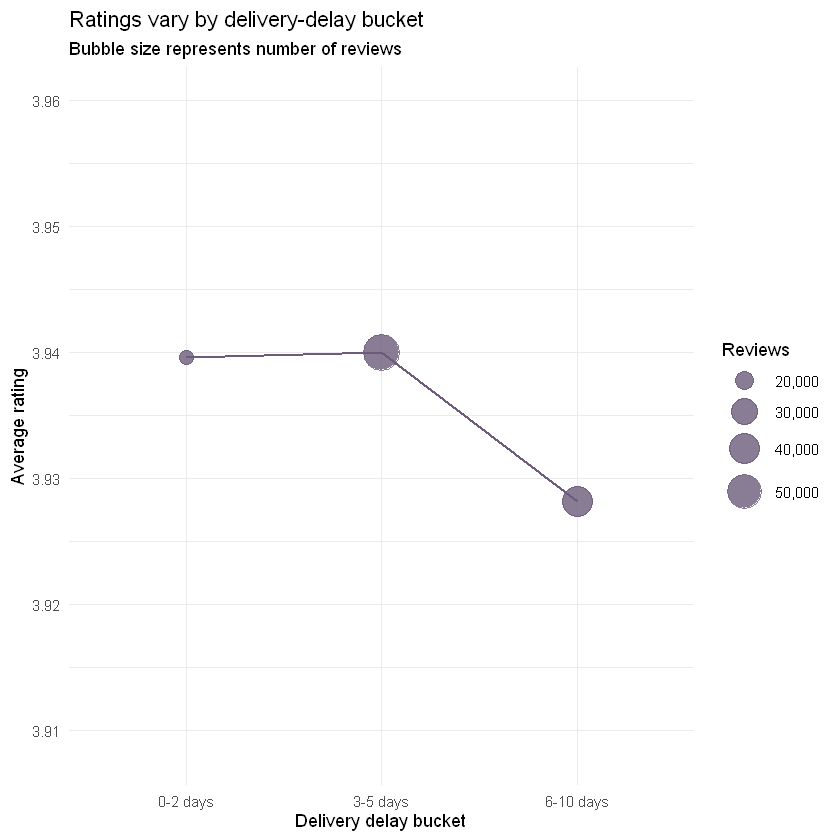

In [ ]:
p4 <- ggplot(shipping_experience_summary, aes(x = delay_bucket, y = avg_rating, group = 1)) +
  geom_line(color = "#6C5B7B", linewidth = 0.8) +
  geom_point(aes(size = reviews), color = "#6C5B7B", alpha = 0.8) +
  scale_size_continuous(labels = label_number(big.mark = ","), range = c(4, 10)) +
  coord_cartesian(ylim = c(min(shipping_experience_summary$avg_rating) - 0.02, max(shipping_experience_summary$avg_rating) + 0.02)) +
  labs(title = "Ratings vary by delivery-delay bucket", subtitle = "Bubble size represents number of reviews", x = "Delivery delay bucket", y = "Average rating", size = "Reviews")

p4
ggsave(file.path(chart_dir, "insight_04_delay_rating.png"), p4, width = 8, height = 5, dpi = 160)


**What it shows:** Rating differences by delivery-delay bucket are small but measurable, so logistics experience should be monitored as part of customer experience.

**Key numbers:** The best rating bucket is **3-5 days** with average rating about **3.94**. The weakest bucket is **6-10 days** with average rating about **3.93**.

**Why it matters:** Even small rating differences can matter at scale, especially when combined with return records and refund amount.

**Implication:** Delay management should focus on high-value or high-return-risk categories rather than blanket shipping upgrades.

**Recommendation:** Create a proactive communication or shipping-priority rule for orders likely to enter the 6-10 day delay bucket, especially for categories already showing high return or refund pressure.


# Theme 4: Inventory And Operations


## Insight 5 - Stockouts create the largest operational revenue risk in the top category

**Business question:** Which categories may be losing sales because inventory cannot keep up with demand?


In [ ]:
monthly_category_demand <- order_lines_enriched |>
  group_by(category, order_month) |>
  summarise(revenue = sum(line_revenue, na.rm = TRUE), units = sum(quantity, na.rm = TRUE), avg_revenue_per_unit = revenue / units, .groups = "drop")

inventory_ops_data <- inventory_monthly |>
  group_by(category, month) |>
  summarise(stockout_days = sum(stockout_days, na.rm = TRUE), avg_fill_rate = mean(fill_rate, na.rm = TRUE), avg_sell_through_rate = mean(sell_through_rate, na.rm = TRUE), units_sold = sum(units_sold, na.rm = TRUE), overstock_months = sum(overstock_flag, na.rm = TRUE), .groups = "drop") |>
  left_join(monthly_category_demand, by = c("category" = "category", "month" = "order_month")) |>
  mutate(avg_revenue_per_unit = ifelse(is.na(avg_revenue_per_unit), median(avg_revenue_per_unit, na.rm = TRUE), avg_revenue_per_unit), lost_sales_proxy = stockout_days * (units_sold / 30) * avg_revenue_per_unit)

inventory_category_summary <- inventory_ops_data |>
  group_by(category) |>
  summarise(stockout_days = sum(stockout_days, na.rm = TRUE), avg_fill_rate = mean(avg_fill_rate, na.rm = TRUE), avg_sell_through_rate = mean(avg_sell_through_rate, na.rm = TRUE), lost_sales_proxy = sum(lost_sales_proxy, na.rm = TRUE), overstock_months = sum(overstock_months, na.rm = TRUE), .groups = "drop") |>
  arrange(desc(lost_sales_proxy))

inventory_category_summary


category,stockout_days,avg_fill_rate,avg_sell_through_rate,lost_sales_proxy,overstock_months
<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>
Streetwear,36993,0.9604603,0.1573081,40007919800,23242
Outdoor,23552,0.9629587,0.1316866,4939801337,16809
GenZ,5368,0.9612777,0.1668361,165448854,3348
Casual,4012,0.9622667,0.1689293,165011425,2543


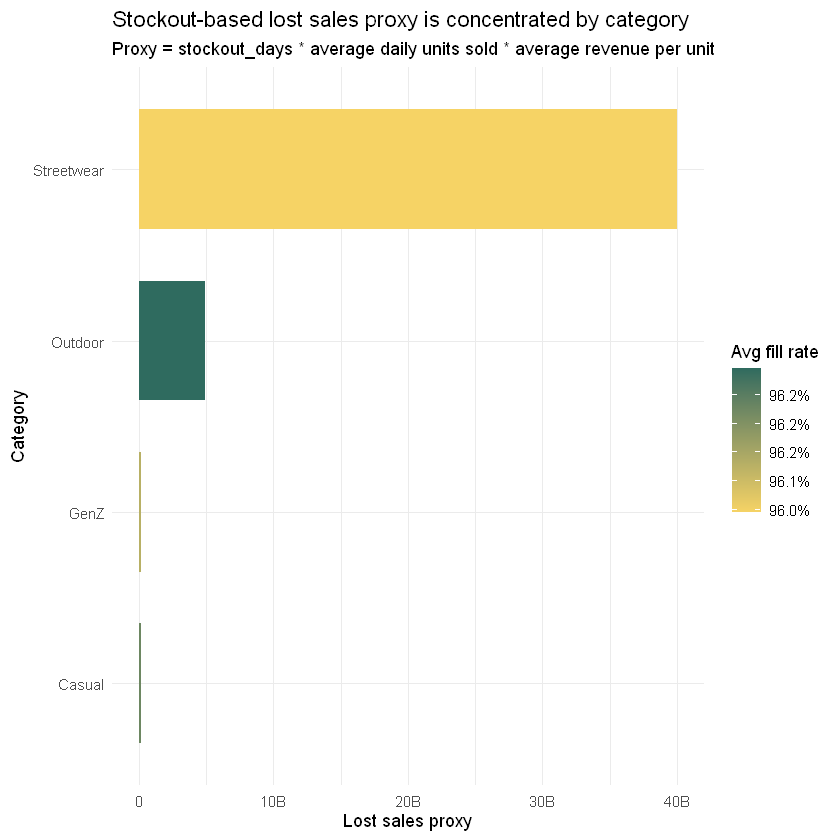

In [ ]:
p5 <- inventory_category_summary |>
  mutate(category = reorder(category, lost_sales_proxy)) |>
  ggplot(aes(x = category, y = lost_sales_proxy, fill = avg_fill_rate)) +
  geom_col(width = 0.7) +
  coord_flip() +
  scale_y_continuous(labels = label_number(scale_cut = cut_short_scale())) +
  scale_fill_gradient(low = "#F6D365", high = "#2F6B5F", labels = percent_format(accuracy = 0.1)) +
  labs(title = "Stockout-based lost sales proxy is concentrated by category", subtitle = "Proxy = stockout_days * average daily units sold * average revenue per unit", x = "Category", y = "Lost sales proxy", fill = "Avg fill rate")

p5
ggsave(file.path(chart_dir, "insight_05_lost_sales_stockout.png"), p5, width = 8, height = 5, dpi = 160)


**What it shows:** Stockout risk is not only an operations metric; it is directly tied to missed revenue opportunity.

**Key numbers:** **Streetwear** has about **36,993** stockout days and average fill rate around **96.02%**. It also has the highest lost-sales proxy, about **40,007,919,800**.

**Why it matters:** Streetwear is also the top revenue category, so stockouts in this category can disproportionately affect total performance.

**Implication:** Inventory policy should prioritize high-revenue, high-stockout categories instead of treating all categories equally.

**Recommendation:** Set higher safety-stock thresholds and earlier reorder triggers for Streetwear before seasonal peaks. Use lost-sales proxy as a prioritization metric for replenishment decisions.


## Insight 6 - Overstock and low sell-through indicate working-capital risk

**Business question:** Where is inventory tying up capital without enough sell-through?


In [ ]:
overstock_data <- inventory_category_summary |> arrange(desc(overstock_months))
overstock_data


category,stockout_days,avg_fill_rate,avg_sell_through_rate,lost_sales_proxy,overstock_months
<chr>,<int>,<dbl>,<dbl>,<dbl>,<int>
Streetwear,36993,0.9604603,0.1573081,40007919800,23242
Outdoor,23552,0.9629587,0.1316866,4939801337,16809
GenZ,5368,0.9612777,0.1668361,165448854,3348
Casual,4012,0.9622667,0.1689293,165011425,2543


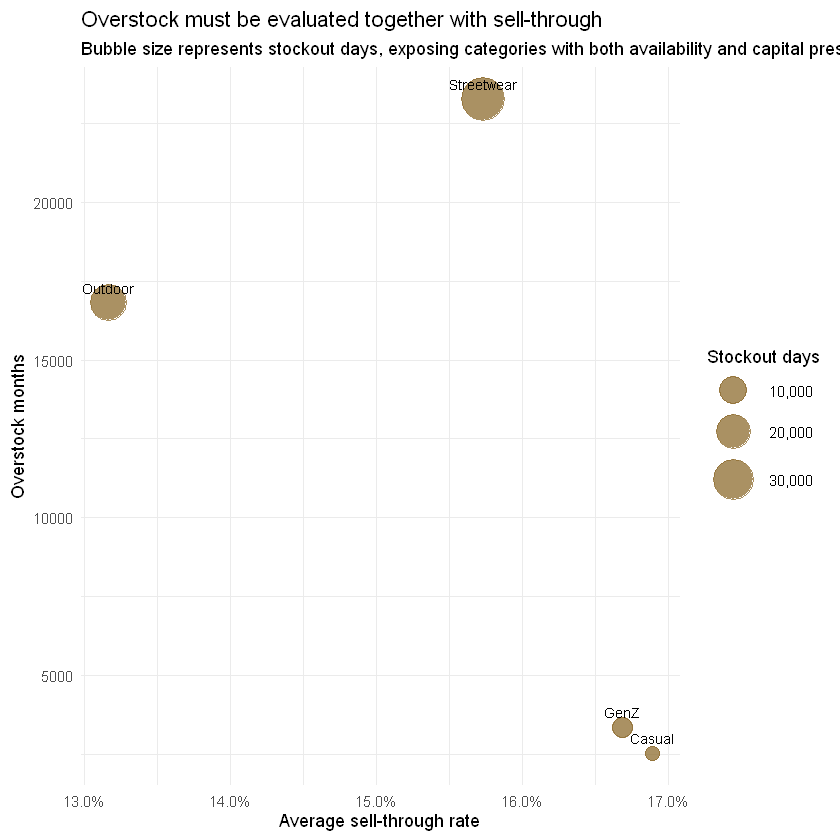

In [ ]:
p6 <- ggplot(overstock_data, aes(x = avg_sell_through_rate, y = overstock_months, size = stockout_days, label = category)) +
  geom_point(color = "#8E6C2F", alpha = 0.75) +
  geom_text(vjust = -0.9, size = 3) +
  scale_x_continuous(labels = percent_format(accuracy = 0.1)) +
  scale_size_continuous(labels = label_number(big.mark = ","), range = c(4, 12)) +
  labs(title = "Overstock must be evaluated together with sell-through", subtitle = "Bubble size represents stockout days, exposing categories with both availability and capital pressure", x = "Average sell-through rate", y = "Overstock months", size = "Stockout days")

p6
ggsave(file.path(chart_dir, "insight_06_overstock_sellthrough.png"), p6, width = 8, height = 5, dpi = 160)


**What it shows:** Overstock and stockout can coexist at category level, which suggests imbalance across products within the same category.

**Key numbers:** **Streetwear** has the highest overstock count with about **23,242** overstock product-months, while average sell-through is about **15.98%**.

**Why it matters:** This means the business may be short on some high-demand SKUs while holding too much of slower-moving variants.

**Implication:** Category-level demand is strong, but SKU-level allocation needs refinement.

**Recommendation:** Do not simply buy more of the whole category. Rebalance within Streetwear: increase replenishment for high-sell-through SKUs, pause or markdown low-sell-through overstocked variants, and review color/size allocation.


## Final Chart List For Report PDF

These are the charts to carry forward into the report or slides. Supporting charts can go to appendix if page space is tight.


In [ ]:
final_chart_list <- tibble::tibble(
  chart_id = c("C1", "C2", "C3", "C4", "C5", "C6"),
  insight = c("Demand seasonality and revenue peaks", "Channel value and repeat behavior", "Return-rate pressure by product group", "Delivery delay and rating risk", "Stockout-based lost sales proxy", "Overstock and sell-through imbalance"),
  file = c("charts/insight_01_monthly_revenue.png", "charts/insight_02_channel_value.png", "charts/insight_03_return_rate.png", "charts/insight_04_delay_rating.png", "charts/insight_05_lost_sales_stockout.png", "charts/insight_06_overstock_sellthrough.png"),
  report_priority = c(1, 2, 3, 4, 5, 6),
  role_in_story = c("Revenue planning anchor", "Marketing and customer channel decision", "Customer experience and refund leakage", "Logistics experience signal", "Operational revenue protection", "Working-capital optimization")
)

write.csv(final_chart_list, file.path(artifact_dir, "final_chart_list.csv"), row.names = FALSE)
final_chart_list


chart_id,insight,file,report_priority,role_in_story
<chr>,<chr>,<chr>,<dbl>,<chr>
C1,Demand seasonality and revenue peaks,charts/insight_01_monthly_revenue.png,1,Revenue planning anchor
C2,Channel value and repeat behavior,charts/insight_02_channel_value.png,2,Marketing and customer channel decision
C3,Return-rate pressure by product group,charts/insight_03_return_rate.png,3,Customer experience and refund leakage
C4,Delivery delay and rating risk,charts/insight_04_delay_rating.png,4,Logistics experience signal
C5,Stockout-based lost sales proxy,charts/insight_05_lost_sales_stockout.png,5,Operational revenue protection
C6,Overstock and sell-through imbalance,charts/insight_06_overstock_sellthrough.png,6,Working-capital optimization


## Final Business Summary

1. Revenue is seasonal and highly concentrated. Streetwear dominates line-item revenue, so demand planning should prioritize the categories that move the business.
2. Channel quality requires multiple metrics. `organic_search` is the largest revenue source, while AOV and bounce-rate differences show why marketing decisions should not rely on sessions alone.
3. Returns are partly preventable. The largest return reason is `wrong_size`, and high-return category-size groups should be targeted with fit guidance and product-page improvements.
4. Delivery experience has measurable rating risk. The rating gap is small, but delay buckets can still support proactive communication and prioritization for high-value orders.
5. Inventory is both a revenue and capital problem. Streetwear shows the highest lost-sales proxy from stockout pressure while also carrying overstock risk, implying SKU-level imbalance.

**Prescriptive direction:** Focus action on a few high-impact levers: Streetwear replenishment before peaks, SKU-level inventory rebalancing, channel KPI redesign around AOV/repeat behavior, and fit-guidance improvements for high-return size-category combinations.


In [ ]:
insight_summary <- tibble::tibble(
  insight_id = paste0("I", 1:6),
  theme = c("Revenue and demand", "Customer and channel", "Returns and experience", "Returns and experience", "Inventory and operations", "Inventory and operations"),
  main_metric = c("Peak month revenue and category revenue share", "Revenue, AOV, orders per customer, bounce rate", "Return rate, return records, refund amount", "Average rating by delivery delay bucket", "Stockout days, fill rate, lost sales proxy", "Overstock months and sell-through rate"),
  recommendation = c("Prioritize high-impact categories before demand peaks.", "Allocate channel spend based on revenue quality, AOV, repeat behavior, and traffic quality.", "Improve sizing guidance for high-return size-category groups.", "Use proactive communication or shipping priority for delay-risk orders.", "Increase safety stock and earlier reorder triggers for high-demand stockout categories.", "Rebalance inventory within categories: replenish winners, markdown or pause slow movers.")
)

write.csv(insight_summary, file.path(artifact_dir, "business_insight_summary.csv"), row.names = FALSE)
insight_summary


insight_id,theme,main_metric,recommendation
<chr>,<chr>,<chr>,<chr>
I1,Revenue and demand,Peak month revenue and category revenue share,Prioritize high-impact categories before demand peaks.
I2,Customer and channel,"Revenue, AOV, orders per customer, bounce rate","Allocate channel spend based on revenue quality, AOV, repeat behavior, and traffic quality."
I3,Returns and experience,"Return rate, return records, refund amount",Improve sizing guidance for high-return size-category groups.
I4,Returns and experience,Average rating by delivery delay bucket,Use proactive communication or shipping priority for delay-risk orders.
I5,Inventory and operations,"Stockout days, fill rate, lost sales proxy",Increase safety stock and earlier reorder triggers for high-demand stockout categories.
I6,Inventory and operations,Overstock months and sell-through rate,"Rebalance inventory within categories: replenish winners, markdown or pause slow movers."
